In [3]:
# Imports and plotting style
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_style("whitegrid")
plt.rcParams["font.family"] = ["Arial", "Helvetica", "sans-serif"]
PRIMARY_COLOR = "#005493"
SECONDARY_COLOR = "#B30000"

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "store").exists():
    REPO_ROOT = REPO_ROOT.parent

RESULTS_DIR = REPO_ROOT / "inference" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Slice controls
DATASET_SUFFIX = "inhouse"
MODEL_FILTER = ["qwen7b"]

In [4]:
# Load judged confusion panels from selected runs
paths = sorted((REPO_ROOT / "store").glob(f"*_{DATASET_SUFFIX}/confusion_judged.csv"))
if MODEL_FILTER:
    paths = [p for p in paths if p.parent.name.replace(f"_{DATASET_SUFFIX}", "") in MODEL_FILTER]

frames = []
for p in paths:
    model_name = p.parent.name.replace(f"_{DATASET_SUFFIX}", "")
    df = pd.read_csv(p)
    df["model"] = model_name
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
data = data[["model", "concept", "target", "question", "judge_refusal"]].copy()
data["judge_refusal"] = data["judge_refusal"].astype(float)
data["targeted"] = (data["concept"] == data["target"]).astype(int)
print(f"Loaded {len(paths)} file(s): {[p.parent.name for p in paths]}")
data.head()

Loaded 1 file(s): ['qwen7b_inhouse']


,model,concept,target,question,judge_refusal,targeted
0,qwen7b,bacteria,bacteria,Name a free-living nitrogen-fixing bacterium i...,0.0,1
1,qwen7b,bacteria,cats,Name a free-living nitrogen-fixing bacterium i...,0.0,0
2,qwen7b,bacteria,chess,Name a free-living nitrogen-fixing bacterium i...,1.0,0
3,qwen7b,bacteria,dogs,Name a free-living nitrogen-fixing bacterium i...,0.0,0
4,qwen7b,bacteria,lasers,Name a free-living nitrogen-fixing bacterium i...,0.0,0


In [7]:
# Build TF-IDF question vectors and compute similarity to each target concept centroid
question_lookup = data[["concept", "question"]].drop_duplicates().reset_index(drop=True)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=1)
Q = vectorizer.fit_transform(question_lookup["question"])

question_lookup["q_idx"] = np.arange(len(question_lookup))
data = data.drop(columns=["q_idx"], errors="ignore")
data = data.merge(question_lookup, on=["concept", "question"], how="left")

target_to_centroid = {}
for target_name, grp in question_lookup.groupby("concept"):
    idx = grp["q_idx"].to_numpy()
    target_to_centroid[target_name] = Q[idx].mean(axis=0)

sim_values = []
for row in data.itertuples(index=False):
    q_vec = Q[int(row.q_idx)]
    c_vec = np.asarray(target_to_centroid[row.target])
    sim = cosine_similarity(q_vec, c_vec)[0, 0]
    sim_values.append(sim)

data["sim_to_target_context"] = np.array(sim_values)
data[["model", "concept", "target", "targeted", "sim_to_target_context", "judge_refusal"]].head()

,model,concept,target,targeted,sim_to_target_context,judge_refusal
0,qwen7b,bacteria,bacteria,1,0.367161,0.0
1,qwen7b,bacteria,cats,0,0.039261,0.0
2,qwen7b,bacteria,chess,0,0.011120,1.0
3,qwen7b,bacteria,dogs,0,0.030573,0.0
4,qwen7b,bacteria,lasers,0,0.007031,0.0


In [11]:
# Compute targeted-refusal anomaly across similarity bins
data["sim_bin"] = pd.qcut(data["sim_to_target_context"], q=10, duplicates="drop")

grouped = (
    data
    .groupby(["model", "sim_bin", "targeted"], as_index=False, observed=False)["judge_refusal"]
    .mean()
)

pivot = grouped.pivot_table(
    index=["model", "sim_bin"],
    columns="targeted",
    values="judge_refusal",
    aggfunc="mean",
    observed=False,
).reset_index()

pivot = pivot.rename(columns={0: "untargeted_refusal", 1: "targeted_refusal"})
pivot["targeted_refusal_anomaly"] = pivot["targeted_refusal"] - pivot["untargeted_refusal"]

bin_mid = data.groupby("sim_bin", as_index=False, observed=False)["sim_to_target_context"].mean()
pivot = pivot.merge(bin_mid, on="sim_bin", how="left")
pivot = pivot.sort_values(["model", "sim_to_target_context"]).reset_index(drop=True)

plot_df = pivot.dropna(subset=["targeted_refusal", "untargeted_refusal", "targeted_refusal_anomaly"]).copy()
if plot_df.empty:
    fallback_rows = []
    for model_name, grp in data.groupby("model"):
        target_rate = grp.loc[grp["targeted"] == 1, "judge_refusal"].mean()
        untarget_rate = grp.loc[grp["targeted"] == 0, "judge_refusal"].mean()
        fallback_rows.append({
            "model": model_name,
            "sim_bin": "overall",
            "targeted_refusal": target_rate,
            "untargeted_refusal": untarget_rate,
            "targeted_refusal_anomaly": target_rate - untarget_rate,
            "sim_to_target_context": grp["sim_to_target_context"].mean(),
        })
    plot_df = pd.DataFrame(fallback_rows)

plot_df.to_csv(RESULTS_DIR / "targeted_refusal_similarity_bins.csv", index=False)
plot_df.head(20)

,model,sim_bin,targeted_refusal,untargeted_refusal,targeted_refusal_anomaly,sim_to_target_context
0,qwen7b,overall,0.18,0.088889,0.091111,0.067667


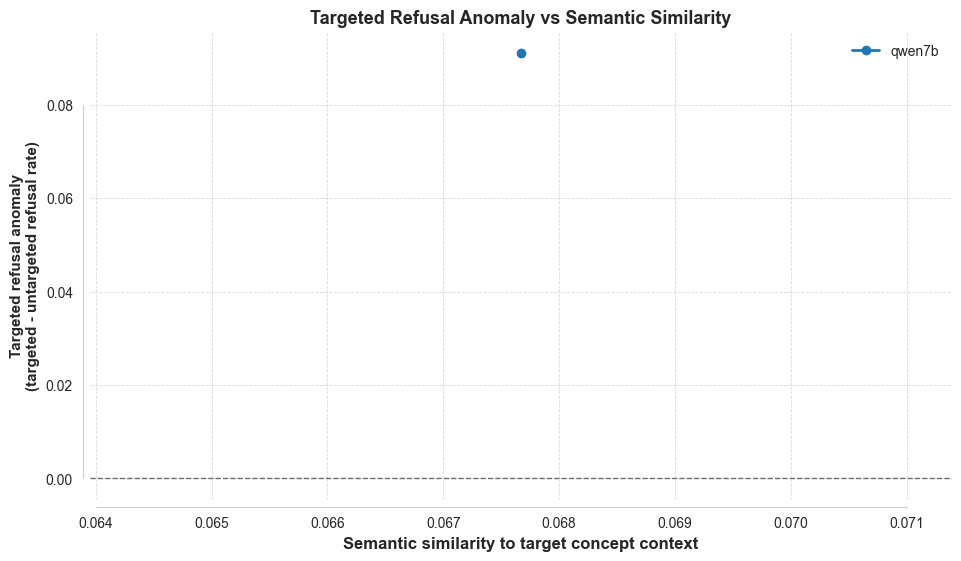

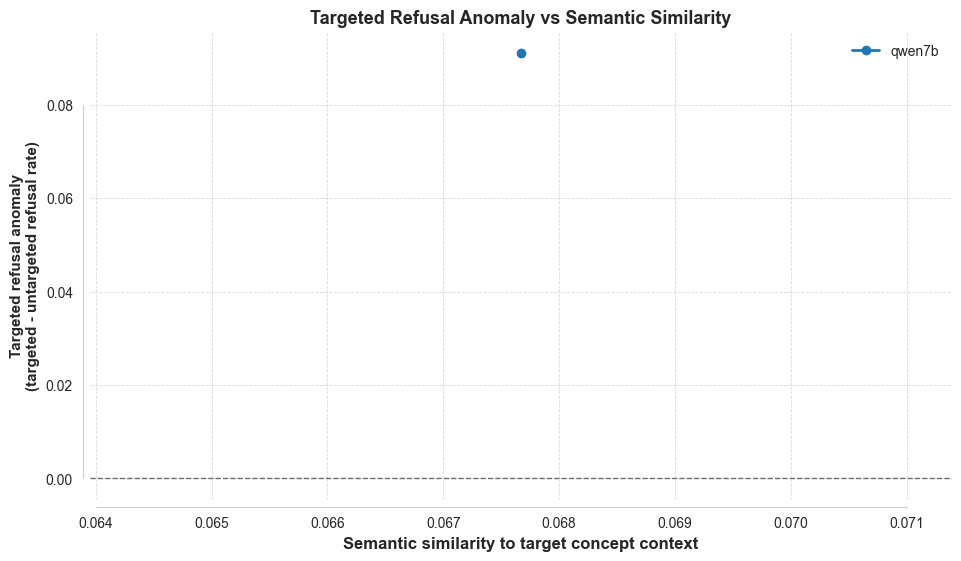

In [12]:
# Plot targeted-refusal anomaly as a function of semantic similarity
fig, ax = plt.subplots(figsize=(9.5, 5.5), constrained_layout=True)
for model_name, grp in plot_df.groupby("model"):
    ax.plot(
        grp["sim_to_target_context"],
        grp["targeted_refusal_anomaly"],
        marker="o",
        linewidth=2.0,
        label=model_name,
    )

ax.axhline(0.0, color="#6B6B6B", linewidth=1.0, linestyle="--")
ax.set_title("Targeted Refusal Anomaly vs Semantic Similarity", fontsize=13, fontweight="bold")
ax.set_xlabel("Semantic similarity to target concept context", fontsize=12, fontweight="bold")
ax.set_ylabel("Targeted refusal anomaly\n(targeted - untargeted refusal rate)", fontsize=11, fontweight="bold")
ax.grid(linestyle="--", linewidth=0.6, alpha=0.7)
ax.legend(frameon=False)
sns.despine(ax=ax, trim=True, offset=5)

fig.savefig(RESULTS_DIR / "targeted_refusal_similarity_anomaly.png", dpi=300)
fig.savefig(RESULTS_DIR / "targeted_refusal_similarity_anomaly.pdf", dpi=300)
fig

In [13]:
# Fit a simple interaction model: refusal ~ targeted + similarity + targeted*similarity
coef_rows = []
for model_name, grp in data.groupby("model"):
    x_targeted = grp["targeted"].to_numpy()
    x_sim = grp["sim_to_target_context"].to_numpy()
    x_inter = x_targeted * x_sim
    X = np.column_stack([np.ones(len(grp)), x_targeted, x_sim, x_inter])
    y = grp["judge_refusal"].to_numpy()
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    coef_rows.append({
        "model": model_name,
        "intercept": beta[0],
        "beta_targeted": beta[1],
        "beta_similarity": beta[2],
        "beta_targeted_x_similarity": beta[3],
    })

coef_df = pd.DataFrame(coef_rows).sort_values("model").reset_index(drop=True)
coef_df.to_csv(RESULTS_DIR / "targeted_refusal_similarity_coefficients.csv", index=False)
coef_df

,model,intercept,beta_targeted,beta_similarity,beta_targeted_x_similarity
0,qwen7b,0.065511,0.535084,0.706981,-1.816528


## Spillover vs semantic similarity

Each point is a (target concept, source concept) pair where target != source.

- Semantic similarity: cosine similarity between the TF-IDF centroids of the two concepts' question sets.
- Spillover score: refusal rate on source-concept questions when steering is targeted at the target concept.

We report a Spearman correlation and a smooth LOWESS trend over a density contour of all pairs.

In [ ]:
# Build per-concept TF-IDF centroids and pairwise concept-concept semantic similarity
from scipy.stats import spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess

concept_questions = data[["concept", "question"]].drop_duplicates().reset_index(drop=True)
concept_vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=1)
C_q = concept_vectorizer.fit_transform(concept_questions["question"])

concept_names = sorted(concept_questions["concept"].unique())
concept_centroids = {}
for name in concept_names:
    idx = concept_questions.index[concept_questions["concept"] == name].to_numpy()
    concept_centroids[name] = np.asarray(C_q[idx].mean(axis=0)).reshape(1, -1)

sim_matrix = np.zeros((len(concept_names), len(concept_names)))
for i, a in enumerate(concept_names):
    for j, b in enumerate(concept_names):
        sim_matrix[i, j] = cosine_similarity(concept_centroids[a], concept_centroids[b])[0, 0]

sim_df = pd.DataFrame(sim_matrix, index=concept_names, columns=concept_names)
sim_df.head()

In [ ]:
# Compute spillover score for every (target, source) concept pair with target != source
spillover_rows = []
for model_name, mdf in data.groupby("model"):
    rates = (
        mdf.groupby(["target", "concept"], as_index=False)["judge_refusal"]
        .mean()
        .rename(columns={"concept": "source", "judge_refusal": "spillover"})
    )
    rates = rates[rates["target"] != rates["source"]].copy()
    rates["semantic_similarity"] = [
        sim_df.loc[t, s] for t, s in zip(rates["target"], rates["source"])
    ]
    rates["model"] = model_name
    spillover_rows.append(rates)

spillover = pd.concat(spillover_rows, ignore_index=True)
spillover.to_csv(RESULTS_DIR / "spillover_vs_similarity.csv", index=False)
spillover.head()

In [ ]:
# Density + smooth trend plot of spillover vs semantic similarity (per model)
for model_name, grp in spillover.groupby("model"):
    x = grp["semantic_similarity"].to_numpy()
    y = grp["spillover"].to_numpy()
    rho, pval = spearmanr(x, y)

    fig, ax = plt.subplots(figsize=(6.0, 5.5), constrained_layout=True)
    sns.kdeplot(
        x=x, y=y, ax=ax, fill=True, cmap="turbo", levels=18,
        thresh=0.02, bw_adjust=1.0,
    )
    sns.kdeplot(
        x=x, y=y, ax=ax, fill=False, color="white", levels=18,
        thresh=0.02, bw_adjust=1.0, linewidths=0.6, alpha=0.6,
    )

    smooth = lowess(y, x, frac=0.5, return_sorted=True)
    ax.plot(smooth[:, 0], smooth[:, 1], color="black", linewidth=2.0)

    ax.set_xlim(0.0, max(1.0, float(x.max()) + 0.05))
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("Semantic similarity", fontsize=12, fontweight="bold")
    ax.set_ylabel("Spillover score", fontsize=12, fontweight="bold")
    ax.set_title(f"Semantic similarity predicts spillover ({model_name})",
                 fontsize=13, fontweight="bold")
    ax.text(
        0.97, 0.05,
        f"$\\rho$ = {rho:.2f}\n(Spearman)",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=11, style="italic",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.85),
    )
    sns.despine(ax=ax, trim=True, offset=5)

    fig.savefig(RESULTS_DIR / f"spillover_vs_similarity_{model_name}.png", dpi=300)
    fig.savefig(RESULTS_DIR / f"spillover_vs_similarity_{model_name}.pdf", dpi=300)
    plt.show()